In [1]:
# importing packages
import matplotlib.pyplot as plt
import ptitprince as pt
import random
import numpy as np
from numpy.random import default_rng
import pandas as pd
import json
from tqdm import tqdm
from scipy import stats, special
import seaborn as sns
import networkx as nx
import pickle
import itertools
from dotmotif import Motif, GrandIsoExecutor
from scipy.stats import kruskal, f_oneway, levene, ranksums, mannwhitneyu, ttest_ind, wilcoxon, norm, chi2_contingency, chisquare, fisher_exact
from statsmodels.stats.multitest import multipletests
from sklearn import mixture
from scipy.interpolate import interp1d
from tabulate import tabulate
from statannotations.Annotator import Annotator
from typing import Tuple, Dict, Any
import warnings, time, random
from requests.exceptions import HTTPError
from scipy.spatial import cKDTree


plt.rcParams.update({'font.size': 20})
plt.rcParams["figure.figsize"] = (10,10)
sns.set_theme(style="whitegrid")
random.seed(747)

# Import Stefan's Library for Data Management of V1DD
from lsmm_data import LSMMData

# Functions

In [2]:
# Set-Wise Comparison Functions: Determining the intersection of assembly assignment of two pyramidal cells 
# These comparison functions map to C in the statistical methods section.
def shared(pre, post, A):
    try:
        return not A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def disjoint(pre, post, A):
    try:
        return A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def shared_a(pre, post, A):
    return (pre not in no_A) and (post not in no_A) # type: ignore

def shared_no_a(pre, post, A):
    return (pre in no_A) and (post in no_A) # type: ignore

def no_a_a(pre, post, A):
    return (pre in no_A) and (post not in no_A) # type: ignore

def a_no_a(pre, post, A):
    return (pre not in no_A) and (post in no_A) # type: ignore

def no_a_to_any(pre, _, A):
    return (pre in no_A) # type: ignore

def a_to_any(pre, _, A):
    return (pre not in no_A) # type: ignore

comparison_functions = [shared, disjoint, shared_a, shared_no_a, no_a_a, a_no_a, no_a_to_any, a_to_any]
groups = ['shared', 'disjoint', 'shared_a', 'shared_no_a']

### effect sizes

In [3]:
# EFFECT SIZES

def _dir_from_alt(alternative: str) -> int:
    if alternative not in ("greater", "less"):
        raise ValueError("alternative must be 'greater' or 'less'")
    return +1 if alternative == "greater" else -1


def _paired_from_dict(comparison_dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    sk = set(comparison_dict.get('shared', {}).keys())
    dk = set(comparison_dict.get('disjoint', {}).keys())
    common = sorted(sk & dk)
    if not common:
        return np.array([]), np.array([]), np.array([])
    s = np.array([comparison_dict["shared"][k] for k in common], float)
    d = np.array([comparison_dict["disjoint"][k] for k in common], float)
    z = s - d
    return s, d, z


# ---------- effect sizes ----------

def cohens_d(shared, disjoint, *, alternative="greater", paired=False) -> float:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size < 2:
            return np.nan
        z = s - d
        sd = np.std(z, ddof=1)
        if not np.isfinite(sd) or sd == 0:
            return np.nan
        return sign * (np.mean(z) / sd)

    n1, n2 = s.size, d.size
    if n1 < 2 or n2 < 2:
        return np.nan
    sp2 = ((n1 - 1)*np.var(s, ddof=1) + (n2 - 1)*np.var(d, ddof=1)) / (n1 + n2 - 2)
    sp = np.sqrt(sp2)
    if not np.isfinite(sp) or sp == 0:
        return np.nan
    return sign * ((np.mean(s) - np.mean(d)) / sp)


def hodges_lehmann(shared, disjoint, *, alternative="greater", paired=False,
                   max_pairs=5_000_000, rng=None, approx_pairs=2_000_000) -> float:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan
        return float(sign * np.median(s - d))

    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan

    total = n1 * n2
    if total <= max_pairs:
        diffs = np.subtract.outer(s, d).ravel()
        base = np.median(diffs)
    else:
        rng = default_rng() if rng is None else rng
        k = int(min(approx_pairs, total))
        diffs = s[rng.integers(0, n1, size=k)] - d[rng.integers(0, n2, size=k)]
        base = np.median(diffs)

    return float(sign * base)

def ps_and_delta(shared, disjoint, *, alternative="greater", paired=False,
                 eps=0.0, method="asymptotic") -> Tuple[float, float]:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan, np.nan
        z = s - d
        wins = np.sum(z >  eps)
        ties = np.sum(np.abs(z) <= eps)
        n    = z.size
        A_sh = (wins + 0.5 * ties) / n   # P(z>0)+0.5P(z=0)
        delta= 2.0*A_sh - 1.0
        return (A_sh, delta) if sign > 0 else (1.0 - A_sh, -delta)

    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan

    U_sh, _ = stats.mannwhitneyu(s, d, alternative="greater", method=method)
    A_sh = U_sh / (n1 * n2)
    delta = 2.0*A_sh - 1.0
    return (A_sh, delta) if sign > 0 else (1.0 - A_sh, -delta)


# ---------- BCa CI implementation (generic) ----------

def _phi_inv(p: float) -> float:
    """
    Inverse CDF (quantile) for the standard normal distribution.
    Uses scipy.stats.norm.ppf for stability.
    """
    return stats.norm.ppf(p)

def _bca_ci_from_boot_and_jack(theta_hat: float, boot: np.ndarray, jack: np.ndarray, alpha=0.05) -> Tuple[float, float]:
    boot = np.asarray(boot, float)
    jack = np.asarray(jack, float)
    B = np.isfinite(boot).sum()
    if B == 0 or jack.size == 0:
        return (np.nan, np.nan)

    # bias-correction z0
    prop_lt = np.mean(boot < theta_hat)
    z0 = _phi_inv(prop_lt)

    # acceleration a via jackknife influence
    jack_mean = np.mean(jack)
    u = jack_mean - jack
    num = np.sum(u**3)
    den = 6.0 * (np.sum(u**2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # adjusted quantiles
    al = alpha/2
    au = 1 - alpha/2
    z_al = _phi_inv(al)
    z_au = _phi_inv(au)

    adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
    adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))

    lo = np.quantile(boot, adj_al, method="nearest")
    hi = np.quantile(boot, adj_au, method="nearest")
    return (float(lo), float(hi))


def _jackknife_stat(effect_fn, s: np.ndarray, d: np.ndarray, *, paired: bool, alternative: str) -> np.ndarray:
    # Leave-one-out across the combined data (pairs as units when paired)
    if paired:
        n = s.size
        out = np.empty(n)
        for i in range(n):
            mask = np.arange(n) != i
            out[i] = effect_fn(s[mask], d[mask], alternative=alternative, paired=True)
        return out
    else:
        n1, n2 = s.size, d.size
        out = np.empty(n1 + n2)
        # leave-one-out from group 1
        for i in range(n1):
            out[i] = effect_fn(np.delete(s, i), d, alternative=alternative, paired=False)
        # leave-one-out from group 2
        for j in range(n2):
            out[n1 + j] = effect_fn(s, np.delete(d, j), alternative=alternative, paired=False)
        return out


def _ci_wrapper(theta_hat, boot_vals, jack_vals, alpha, method="bca"):
    boot_vals = np.asarray(boot_vals)
    if method == "percentile" or jack_vals.size == 0:
        return (float(np.percentile(boot_vals, 2.5)),
                float(np.percentile(boot_vals, 97.5)))
    elif method == "bca":
        try:
            return _bca_ci_from_boot_and_jack(theta_hat, boot_vals, jack_vals, alpha)
        except ValueError:
            # fallback if adjusted quantiles go out of bounds
            return (float(np.percentile(boot_vals, 2.5)),
                    float(np.percentile(boot_vals, 97.5)))


# ---------- main: bootstrap + reporting ----------

def bootstrap_effects_and_p(
    comparison_dict: Dict[str, Dict[Any, float]],
    *,
    B: int = 1_000,
    seed: int = 747,
    alternative: str = "greater",
    non_zero: bool = False,
    alpha: float = 0.05,
    hl_max_pairs: int = 5_000_000,
    paired: bool = False,
    eps_tie: float = 0.0,
    mw_method: str = "asymptotic",
) -> Dict[str, Any]:

    rng = default_rng(seed)
    sign = _dir_from_alt(alternative)

    # ---------- build data ----------
    if paired:
        s, d, z = _paired_from_dict(comparison_dict)
        if non_zero:
            mask = (s != 0) & (d != 0)
            s, d, z = s[mask], d[mask], z[mask]
        if z.size == 0:
            raise ValueError("No common keys for paired analysis after filtering.")
    else:
        s = np.array(list(comparison_dict["shared"].values()), float)
        d = np.array(list(comparison_dict["disjoint"].values()), float)
        if non_zero:
            s = s[s != 0]
            d = d[d != 0]
        if s.size == 0 or d.size == 0:
            raise ValueError("Empty group(s) for unpaired analysis after filtering.")

    # ---------- point estimates ----------
    d_hat   = cohens_d(s, d, alternative=alternative, paired=paired)
    HL_hat  = hodges_lehmann(s, d, alternative=alternative, paired=paired,
                             max_pairs=hl_max_pairs, rng=rng)
    PS_hat, delta_hat = ps_and_delta(s, d, alternative=alternative, paired=paired,
                                     eps=eps_tie, method=mw_method)

    # test (Wilcoxon or Mann–Whitney)
    if paired:
        alt = "greater" if sign > 0 else "less"
        sr = stats.wilcoxon(s, d, alternative=alt)
        p_point = float(sr.pvalue)
        median_info = f"Median paired difference = {np.median(s - d):.6g}"
    else:
        alt = "greater" if sign > 0 else "less"
        mw = stats.mannwhitneyu(s, d, alternative=alt, method=mw_method)
        p_point = float(mw.pvalue)
        median_info = f"Shared median = {np.median(s):.6g}, Disjoint median = {np.median(d):.6g}"

    # ---------- bootstrap ----------
    if paired:
        n = s.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            sb, db = s[idx], d[idx]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=True)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=True)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=True, eps=eps_tie)
            ps_b[b], delta_b[b] = A_b, del_b
    else:
        n1, n2 = s.size, d.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            si = rng.integers(0, n1, size=n1)
            di = rng.integers(0, n2, size=n2)
            sb, db = s[si], d[di]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=False)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=False,
                                     max_pairs=hl_max_pairs, rng=rng)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=False, method=mw_method)
            ps_b[b], delta_b[b] = A_b, del_b

    # ---------- jackknife for BCa ----------
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        try:
            jack_d    = _jackknife_stat(cohens_d,        s, d, paired=paired, alternative=alternative)
            jack_hl   = _jackknife_stat(hodges_lehmann,  s, d, paired=paired, alternative=alternative)
            jack_ps   = _jackknife_stat(lambda a,b,**kw: ps_and_delta(a,b,**kw)[0],
                                        s, d, paired=paired, alternative=alternative)
            jack_del  = 2.0*jack_ps - 1.0
        except Exception:
            jack_d = jack_hl = jack_ps = jack_del = np.array([])

    # ---------- percentile CIs ----------
    d_CI_pct     = _ci_wrapper(d_hat,   d_b,    np.array([]), alpha, method="percentile")
    hl_CI_pct    = _ci_wrapper(HL_hat,  hl_b,   np.array([]), alpha, method="percentile")
    ps_CI_pct    = _ci_wrapper(PS_hat,  ps_b,   np.array([]), alpha, method="percentile")
    delta_CI_pct = _ci_wrapper(delta_hat, delta_b, np.array([]), alpha, method="percentile")

    # ---------- BCa CIs ----------
    d_CI_bca     = _ci_wrapper(d_hat,   d_b,    jack_d,   alpha, method="bca")
    hl_CI_bca    = _ci_wrapper(HL_hat,  hl_b,   jack_hl,  alpha, method="bca")
    ps_CI_bca    = _ci_wrapper(PS_hat,  ps_b,   jack_ps,  alpha, method="bca")
    delta_CI_bca = _ci_wrapper(delta_hat, delta_b, jack_del, alpha, method="bca")

    # ---------- console output ----------
    mode = "PAIRED" if paired else "UNPAIRED"
    n_info = f"n_pairs={len(s)}" if paired else f"n1={len(s)}, n2={len(d)}"

    print(f"\n[{mode}] Effect sizes (pos = '{alternative}')  {n_info}")
    print(f"  Test p-value: {p_point:.4g}")
    print(f"  {median_info}")

    print("\n  Effect sizes with bootstrapped 95% CI (percentile):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_pct[0]:.6g}, {hl_CI_pct[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_pct[0]:.3f}, {ps_CI_pct[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_pct[0]:.3f}, {delta_CI_pct[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_pct[0]:.3f}, {d_CI_pct[1]:.3f}]")

    print("\n  Effect sizes with bootstrapped 95% CI (BCa):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_bca[0]:.6g}, {hl_CI_bca[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_bca[0]:.3f}, {ps_CI_bca[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_bca[0]:.3f}, {delta_CI_bca[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_bca[0]:.3f}, {d_CI_bca[1]:.3f}]")

    # ---------- results dict ----------
    results = {
        "paired": paired,
        "alternative": alternative,
        "non_zero": non_zero,
        "B": B,
        "point": {"p_value": p_point, "d": float(d_hat), "HL": float(HL_hat),
                  "PS": float(PS_hat), "delta": float(delta_hat)},
        "CI95_percentile": {"d": d_CI_pct, "HL": hl_CI_pct, "PS": ps_CI_pct, "delta": delta_CI_pct},
        "CI95_bca": {"d": d_CI_bca, "HL": hl_CI_bca, "PS": ps_CI_bca, "delta": delta_CI_bca},
        "n": (len(s), len(d)) if not paired else (len(s),),
    }

    return results

### analysis and plotting

In [4]:
def save_figure(figure_name):
        plt.savefig(
        f"./draft_figures/{figure_name}.png",
        dpi=500,
        bbox_inches="tight")

def chi_squared_analysis(data, save=False, figure_name=None):
    """
    Perform an overall chi-squared test of independence on a contingency table and display
    observed and expected values as pretty tables with test results.

    Parameters:
    data (pd.DataFrame): A DataFrame representing the contingency table.

    Returns:
    None: Prints the tables and results directly.
    """
    # Perform chi-squared test
    chi2, p, dof, expected = chi2_contingency(data)
    expected_df = pd.DataFrame(expected, index=data.index, columns=data.columns)

    # Create pretty tables
    observed_table = tabulate(
        [[row] + list(data.loc[row]) for row in data.index],
        headers=["Connection Type"] + list(data.columns),
        tablefmt="pretty"
    )
    expected_table = tabulate(
        [[row] + [f"{val:.2f}" for val in expected_df.loc[row]] for row in expected_df.index],
        headers=["Connection Type"] + list(expected_df.columns),
        tablefmt="pretty"
    )

    # Print the results
    print("Observed Contingency Table:")
    print(observed_table, "\n")
    print("Expected Contingency Table:")
    print(expected_table, "\n")
    print("Chi-squared Test Results:")
    print(f"Chi-squared Statistic: {chi2:.4f}")
    print(f"Degrees of Freedom: {dof}")
    print(f"P-value: {p:.4g}")

    # Plot the heatmap with updated annotation and tick font sizes
    plt.figure(figsize=(6, 3))
    sns.set_theme(style="whitegrid")

    # Create a custom uniform heatmap
    ax = sns.heatmap(
        data,
        annot=True,               # Add annotations for the counts
        fmt="d",                  # Integer format for annotations
        cmap=sns.color_palette(["lightgrey"], as_cmap=True),  # All cells the same light gray color
        cbar=False,               # Remove the color bar
        annot_kws={"fontsize": 22},  # Set font size for annotations
        linewidths=2,             # Add grid lines
        linecolor='black'         # Grid line color
    )

    # Add title and labels
    plt.title(f"Probability of Connection\nChi-squared P-value: {p:.2g}", size=24)
    plt.xlabel("Connection Status", size=22)
    plt.ylabel("Connection Type", size=22)
    plt.xticks(fontsize=22)
    ax.set_yticklabels(data.index, rotation=90, va='center', fontsize=22)


    if save==True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()

def chi_squared_analysis_v2(data, save=False, figure_name=None):
    """
    Perform an overall chi-squared test of independence on a contingency table and display
    observed and expected values as pretty tables with test results. This version plots a 
    heatmap of the *cell-wise chi-square contributions* (rather than the raw counts), 
    to visualize which cells contribute most to the chi-square statistic.

    Parameters:
    data (pd.DataFrame): A DataFrame representing the contingency table constructed from the
                         `construct_contingency_table` function.
    save (bool): Whether to save the resulting plot.
    figure_name (str or None): The filename to use if saving the plot.

    Returns:
    None: Prints the tables and results directly.
    """
    # Perform chi-squared test
    chi2, p, dof, expected = chi2_contingency(data)
    expected_df = pd.DataFrame(expected, index=data.index, columns=data.columns)

    # Create pretty tables
    observed_table = tabulate(
        [[row] + list(data.loc[row]) for row in data.index],
        headers=["Connection Type"] + list(data.columns),
        tablefmt="pretty"
    )
    expected_table = tabulate(
        [[row] + [f"{val:.2f}" for val in expected_df.loc[row]] for row in expected_df.index],
        headers=["Connection Type"] + list(expected_df.columns),
        tablefmt="pretty"
    )

    # Print the results
    print("Observed Contingency Table:")
    print(observed_table, "\n")
    print("Expected Contingency Table:")
    print(expected_table, "\n")
    print("Chi-squared Test Results:")
    print(f"Chi-squared Statistic: {chi2:.4f}")
    print(f"Degrees of Freedom: {dof}")
    print(f"P-value: {p:.4g}")

    # # Calculate the cell-wise contributions
    # contributions = (data - expected_df) ** 2 / expected_df
    # contributions = contributions.fillna(0)  # Replace NaN with 0 for cells with no expected count

    # Calculate directional cell-wise contributions using Pearson residuals
    residuals = (data - expected_df) / np.sqrt(expected_df)
    residuals = residuals.fillna(0)  # Replace NaN values if any expected count is zero

    # Plot the heatmap with updated annotation and tick font sizes
    plt.figure(figsize=(6, 3))
    sns.set_theme(style="whitegrid")

    # Create a custom uniform heatmap
    ax = sns.heatmap(
        residuals,
        annot=True,               # Add annotations for the counts
        fmt=".2f",                  # Integer format for annotations
        cmap=sns.color_palette(["lightgrey"], as_cmap=True),  # All cells the same light gray color
        cbar=False,               # Remove the color bar
        annot_kws={"fontsize": 24},  # Set font size for annotations
        linewidths=2,             # Add grid lines
        linecolor='black'         # Grid line color
    )

    # Add title and labels
    plt.title(f"Chi-Square Pearson Residuals\nP-value: {p:.2g}",size=24)
    plt.xlabel("Connection Status", size=24)
    plt.ylabel("Connection Type", size=24)
    plt.xticks(fontsize=22)
    ax.set_yticklabels(data.index, rotation=90, va='center', fontsize=22)


    if save==True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()

def construct_contingency_table(data_dict, groups):
    # Generate lists for connected and not connected counts
    connected_counts = [sum(1 for _, val in data_dict[group].items() if val == 1) for group in groups]
    not_connected_counts = [sum(1 for _, val in data_dict[group].items() if val == 0) for group in groups]
    
    # Create the DataFrame
    return pd.DataFrame({
        'Connected': connected_counts,
        'Not Connected': not_connected_counts
    }, index=[group.capitalize() for group in groups])

def plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val, save=False, figure_name=None):
    """
    Plots a raincloud plot for two connection type groups, with sample sizes in the y-axis labels.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """
    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Data frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Set up the plot
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="whitegrid")

    # Create the raincloud plot
    ax = pt.RainCloud(
        y="Values",
        x="Group",
        data=data,  
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,  
        alpha=0.8,  
        move=0.25,
        point_size = 6,  
        orient="v" 
    )

    # Set markings for significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax, 
                    pairs,
                    data=data,
                    x="Group",
                    y="Values",
                    order=y_labels # Force the order
                    )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=30)
    annot.annotate()

    # Add plot title and labels
    plt.title(title, size=30)
    plt.xlabel("Connection Type", size=26)
    plt.ylabel(y_lab, size=26)
    plt.xticks(fontsize = 26)
    plt.yticks(fontsize = 26)

    if save == True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()
    plt.close()

def plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, 
                                           y_lab, p_val, for_chains = True,
                                           save=False, figure_name=None
):
    """
    Plots a raincloud plot comparing connection types, 
    plus a smaller side subplot summarizing mean ± SEM for each group.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """

    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Build a frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Compute the statistics for the side plot
    # (Assuming values > 0 for simplicity; modify if needed.)
    shared_log = np.log10(shared_values)
    disjoint_log = np.log10(disjoint_values)

    mean_shared_log = np.mean(shared_log)
    mean_disjoint_log = np.mean(disjoint_log)
    sem_shared_log = stats.sem(shared_log, ddof=1) if n_shared > 1 else 0
    sem_disjoint_log = stats.sem(disjoint_log, ddof=1) if n_disjoint > 1 else 0

    # Set up a figure with two subplots
    fig = plt.figure(figsize=(15, 10))
    # Allocate 2 columns with a narrower column on the right
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[3, 1], wspace=0.3)
    
    # Set up styling
    ax_main = fig.add_subplot(gs[0])
    ax_side = fig.add_subplot(gs[1])
    sns.set_theme(style="whitegrid")

    # --- Main plot (original RainCloud) ---
    pt.RainCloud(
        y="Values",
        x="Group",
        data=data,
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,
        alpha=0.8,
        move=0.25,
        point_size=6,
        orient="v",
        ax=ax_main
    )

    # Annotate significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax_main, 
                      pairs,
                      data=data,
                      x="Group",
                      y="Values",
                      order=y_labels # Force the order
                      )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=28)
    annot.annotate()

    # Axis title and labels
    ax_main.set_title(title, size=24)
    ax_main.set_xlabel("Connection Type", size=24)
    ax_main.set_ylabel(y_lab, size=24)
    ax_main.tick_params(labelsize=24)
    ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax_main.yaxis.get_offset_text().set_fontsize(24)


    # --- Side plot (Mean ± SEM of log(data))---
    # Currently place two horizontal lines and use fill_between for each ± sem region.

    x_vals = [1, 2]  # x positions for shared and disjoint
    mean_logs = [mean_shared_log, mean_disjoint_log]
    sem_logs = [sem_shared_log, sem_disjoint_log]
    colors = [(0.4, 0.6, 0.8, 0.8), 'grey']

    for i, x in enumerate(x_vals):
        m_log = mean_logs[i]
        s_log = sem_logs[i]
        c = colors[i]

        # Horizontal line for mean
        ax_side.hlines(
            y = m_log, 
            xmin = x - 0.15, 
            xmax = x + 0.15, 
            color = c, 
            linewidth = 3
        )
        # Shaded area for ± SEM
        ax_side.fill_betweenx(
            y = [m_log - s_log, m_log + s_log],
            x1 = x - 0.15,
            x2 = x + 0.15,
            color = c,
            alpha = 0.4
        )

    # Tidy up side axis
    ax_side.set_title("Mean ± SEM", size=24)
    ax_side.set_xlim(0.5, 2.5)  
    ax_side.set_xticks(x_vals)
    ax_side.set_xticklabels(["Shared", "Disjoint"], fontsize=24)
    ax_side.tick_params(axis='y', labelsize=24)
    # Show that y-values are on a log base 10 scale
    if for_chains:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight Products) $(\mathrm{\mu m^6})$", size=24)
    else:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight) $(\mathrm{\mu m^3})$", size=24)

    if save and figure_name is not None:
        save_figure(figure_name + "_with_side_plot")

    plt.tight_layout()
    plt.show()
    plt.close()


def ranksum_signedrank_two_group_comparison(comparison_dict, aggregation_method="by connection", directionality=None, data_type="binary", 
                            paired=False, non_zero=False, chain_test = False, chain_description = "Excitatory", save=True, figure_name=None, title_prefix = ""):
    """
    Compares 'shared' and 'disjoint' groups based on connection type and data type.
    Uses a one-sided Wilcoxon rank-sum test and performs a Wilcoxon signed-rank test if paired=True.

    Parameters:
    - comparison_dict (dict): Dictionary with 'shared' and 'disjoint' data.
    - aggregation_method (str): Type of connection ('connection' for pairwise, 'cell' for inbound/outbound by cell).
    - directionality (str): Direction of connectivity for 'cell' type ('inbound' or 'outbound').
    - data_type (str): Data type ('binary' for connectivity, 'synaptic_count' for synaptic counts, 'summed_psd' for nonzero PSD).
    - paired (bool): If True, performs an additional Wilcoxon signed-rank test on paired data.
    - non_zero (bool): If True, filters out zero entries for summed PSD.
    - chain_test (bool): If True, the test is considering chains.
    - chain_description (str): Type of intermediate cell in chain ('excitatory' or 'inhibitory')
    """

    # Set title and labels based on connection_type and data_type
    if aggregation_method == "connection":  # Pairwise connections
        if data_type == "binary":
            title = "Binary Connectivity"
            y_lab = "Binary Connections"
            folder = "pairwise_binary_connectivity"
        elif data_type == "synaptic_count":
            if non_zero == True:
                title = "Synaptic Counts"
                y_lab = "Nonzero Synaptic Count"
                folder = 'synaptic_count'
        elif data_type == "summed_psd":
            if non_zero == True:
                title = "Synaptic Weight"
                y_lab = "Nonzero Synaptic Weight (\u03bcm$^3$)"
                # title = "Nonzero Summed PSD"
                # y_lab = "Nonzero Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_nonzero_summed_psd"
            else:
                title = "Synaptic Weight"
                y_lab = "Synaptic Weight (\u03bcm$^3$)"
                # title = "Summed PSD"
                # y_lab = "Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_summed_psd"
        else:
            raise ValueError("Invalid data_type for pairwise connection.")

    elif aggregation_method == "cell":  # By cell with inbound/outbound directionality
        if directionality not in ["inbound", "outbound"]:
            raise ValueError("For 'cell' connection_type, directionality must be 'inbound' or 'outbound'.")
        
        if data_type == "binary":
            title = f"Probability of {directionality.capitalize()} Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Connection"
            folder = f"{directionality}_connection_probability"
        elif data_type == "synaptic_count":
            title = f"Average Nonzero {directionality.capitalize()} Synaptic Count by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} Synaptic Count"
            folder = f"{directionality}_average_nonzero_synaptic_count"
        elif data_type == "summed_psd":
            title = f"Average Nonzero {directionality.capitalize()} PSD by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} PSD (\u03bcm$^3$)"
            folder = f"{directionality}_average_nonzero_psd"
        else:
            raise ValueError("Invalid data_type for inbound/outbound connection.")
    else:
        raise ValueError("Invalid connection_type. Must be 'connection' or 'cell'.")

    if chain_test:
        if directionality == None:
            title = f"{chain_description} Chain Weight Proucts"
            y_lab = "Synaptic Weight Products"
        elif data_type == 'binary':
            title = f"Probability of {directionality.capitalize()} Chain Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Chain Connection"
        elif data_type == 'summed_psd':
            title = f"Average Nonzero {directionality.capitalize()} PSD Chain Product by Cell"
            y_lab = "Synaptic Weight Products"

    shared_values = np.array(list(comparison_dict["shared"].values()))
    disjoint_values = np.array(list(comparison_dict["disjoint"].values()))
    # Filter out zeros if non_zero is specified for summed_psd
    if non_zero and (data_type == "summed_psd" or data_type == 'synaptic_count'):
        shared_values = shared_values[shared_values != 0]
        disjoint_values = disjoint_values[disjoint_values != 0]

    # Perform the Wilcoxon rank-sum test (one-sided, shared > disjoint)
    if chain_description=='Inhibitory':
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='less')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='less')
    else:
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='greater')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='greater')

    title = f'{title}\nRank-Sum P-value: {rank_sum_p:.2g}'
    # If paired=True, also perform a Wilcoxon signed-rank test on paired observations
    if paired:
        shared_keys = set(comparison_dict.get('shared', {}).keys())
        disjoint_keys = set(comparison_dict.get('disjoint', {}).keys())
        common_keys = shared_keys & disjoint_keys

        if common_keys:
            # Extract paired data for common keys
            shared_paired = np.array([comparison_dict["shared"][key] for key in common_keys])
            disjoint_paired = np.array([comparison_dict["disjoint"][key] for key in common_keys])

            # Perform Wilcoxon signed-rank test on paired data
            if chain_description=='Inhibitory':
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='less')
                print(f"Wilcoxon Signed-Rank Test (paired, shared < disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='less')
            else:
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='greater')
                print(f"Wilcoxon Signed-Rank Test (paired, shared > disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='greater')
            title = f'{title}, Signed-Rank P-value: {signed_rank_p:.2g}'
        else:
            print("No common observations found for paired analysis.")
    title = f'{title_prefix}{title}' 
    # plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, figure_name=figure_name)
    for_chains = True if chain_test else False
    plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, for_chains = for_chains, figure_name=figure_name)

def synaptic_count_histogram(values_dict, connection_type, save=False, figure_name=None):
    """
    Plots a histogram of synaptic counts for a given connection type, using integer bins,
    with frequency labels on each bar.

    Parameters:
    - values_dict: dict of {(pre, post): count} pairs
    - connection_type: str, e.g., 'shared', 'disjoint', etc.
    - save: bool, whether to save the figure
    - figure_name: str, path to save the figure if save is True
    """
    values = list(values_dict.values())
    if not values:
        print(f"No values to plot for connection type: {connection_type}")
        return

    max_val = max(values)
    bins = range(0, max_val + 2)  # +2 to include max_val itself as upper bound

    plt.figure(figsize=(8, 6))
    counts, bins, patches = plt.hist(
        values,
        bins=bins,
        color=(0.4, 0.6, 0.8, 0.5),  # semi-transparent blue fill
        edgecolor="grey",
        alpha=0.8,            # grey borders
        align="left"
    )

    plt.title(f'Histogram of Synaptic Counts for {connection_type.capitalize()} Connections')
    plt.xlabel('Synaptic Count')
    plt.ylabel('Frequency')
    plt.xticks(bins)  # show every integer tick
    plt.xlim(left=0, right=max_val + 1)

    # Add frequency labels on top of each bar
    for bin_edge, count in zip(bins, counts):
        if count > 0:
            plt.text(bin_edge, count + 0.5, str(int(count)),
                     ha='center', va='bottom', fontsize=9)

    plt.tight_layout()

    # if save and figure_name is not None:
    #     save_figure(figure_name)

    plt.show()
    plt.close()

# Load and set data up

In [5]:
# Pull Data from LSMM Data
with open('all_cells_rectangular_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Generating Connectome...


100%|██████████| 813407/813407 [42:10<00:00, 321.48it/s] 


Generating Connectome...


100%|██████████| 813407/813407 [4:30:35<00:00, 50.10it/s]     


In [6]:
# Make a graph
pre_cell_table = data_a['structural']['pre_cell'].copy()
post_cell_table = data_a['structural']['post_cell'].copy() 
pre_cell_table['connectome_index'] = pre_cell_table.index
post_cell_table['connectome_index'] = post_cell_table.index
synapse_table = data_a['structural']['synapse']
adjacency_matrix = data_a['structural']['binary_connectome']
cell_graph = nx.DiGraph()

# Add edges to the graph
rows, cols = data_a['structural']['binary_connectome'].shape
for i in range(rows):
    for j in range(cols):
        if data_a['structural']['binary_connectome'][i, j] != 0:  # 0 means no edge
            cell_graph.add_edge(pre_cell_table.iloc[i]['pt_root_id'], post_cell_table.iloc[j]['pt_root_id'], weight=data_a['structural']['summed_size_connectome'][i, j])

synapse_table = data_a['structural']['synapse']
# adjacency_matrix = data_a['structural']['binary_connectome']
binary_connectome = data_a['structural']['binary_connectome']

index_to_pre_root_id = [mappings_a['connectome_index_to_root_id'][i] for i in range(binary_connectome.shape[0])]
index_to_post_root_id = [mappings_a['post_connectome_index_to_root_id'][i] for i in range(binary_connectome.shape[1])]

summed_size_connectome = data_a['structural']['summed_size_connectome']
summed_size_connectome_df = pd.DataFrame(
    summed_size_connectome,
    index=index_to_pre_root_id,
    columns=index_to_post_root_id
)

synapse_count_connectome = data_a['structural']['synapse_count_connectome']
synapse_count_connectome_df = pd.DataFrame(
    synapse_count_connectome,
    index=index_to_pre_root_id,
    columns=index_to_post_root_id
)

# Or uncomment below to generate new motif analysis results (Can take quite a while on larger graphs)
# Motif Analysis with DotMotif: 2 Chain, All Pyr
executor = GrandIsoExecutor(graph= cell_graph)
chain_defs = Motif("""
                A -> B
                B -> C
              """)

chain_results = executor.find(chain_defs)

two_chain_results_array = np.array([list(c.values()) for c in tqdm(chain_results)])

100%|██████████| 36431187/36431187 [00:38<00:00, 958186.37it/s] 


In [7]:
# get the pre pt root id for connectome indexes by assembly
pre_pt_root_id_by_assembly = {}
for a,idx in mappings_a['connectome_indexes_by_assembly'].items():
    pre_pt_root_id_by_assembly[a] = []
    for i in idx:
       pre_pt_root_id_by_assembly[a].append(mappings_a['connectome_index_to_root_id'][i])  

# get the post pt root id for connectome indexes by assembly
post_pt_root_id_by_assembly = {}
for a,idx in mappings_a['post_connectome_indexes_by_assembly'].items():
    post_pt_root_id_by_assembly[a] = []
    for i in idx:
       post_pt_root_id_by_assembly[a].append(mappings_a['post_connectome_index_to_root_id'][i]) 

### Pool necessary Data
chain_count_string_array = ['pyr_cell_2chain']
individual_pre_assembly_root_ids = [pre_pt_root_id_by_assembly[f'A {i}'] for i in range(1,16)]
individual_post_assembly_root_ids = [post_pt_root_id_by_assembly[f'A {i}'] for i in range(1,16)]


individual_assembly_indexes = [mappings_a['connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]
individual_post_assembly_indexes = [mappings_a['post_connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]

coregistered_post_cell_root_ids = v1dd_data._invert_dict(post_pt_root_id_by_assembly).keys()  #gives assemblies by post_pt_root_id
coregistered_pre_cell_root_ids =  v1dd_data._invert_dict(pre_pt_root_id_by_assembly).keys() # gives assemblies by pre_pt_root_id

no_a_pre_cell_root_ids = pre_pt_root_id_by_assembly['No A']  # HAVE THIS
no_a_post_cell_root_ids = post_pt_root_id_by_assembly['No A'] # HAVE THIS
pooled_assembly_root_ids = list(set(coregistered_pre_cell_root_ids) - set(no_a_pre_cell_root_ids))
pooled_assembly_post_root_ids = list(set(coregistered_post_cell_root_ids) - set(no_a_post_cell_root_ids))

assembly_to_root_ids = mappings_a['pt_root_ids_by_assembly']
assembly_root_ids_set = set(mappings_a['assemblies_by_pt_root_id'].keys())

# Filter synapses_table to only synapses between two assembly cells (including No A)
synapses_df = synapse_table[synapse_table['pre_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df = synapses_df[synapses_df['post_pt_root_id'].isin(assembly_root_ids_set)]

# Filter cell tables to only assembly cells (including 'No A')
assembly_pre_cell_table = pre_cell_table[pre_cell_table['pt_root_id'].isin(assembly_root_ids_set)]
assembly_post_cell_table = post_cell_table[post_cell_table['pt_root_id'].isin(assembly_root_ids_set)]

assembly_pre_root_ids = set(assembly_pre_cell_table['pt_root_id'].values)
assembly_post_root_ids = set(assembly_post_cell_table['pt_root_id'].values)
all_root_ids = assembly_pre_root_ids | assembly_post_root_ids

In [8]:
# Split out assemblies and no_a
assembly_names = set(assembly_to_root_ids.keys()) - set(['No A'])
A_invert = {assembly: set(assembly_to_root_ids[assembly]) for assembly in assembly_names}
no_A = set(assembly_to_root_ids['No A'])
all_coregistered_root_ids = mappings_a['assemblies_by_pt_root_id'].keys()
assembly_root_ids_excluding_no_A = set(all_coregistered_root_ids) - no_A
A = {pt_root_id: set(mappings_a['assemblies_by_pt_root_id'][pt_root_id]) for pt_root_id in all_root_ids if 'No A' not in mappings_a['assemblies_by_pt_root_id'][pt_root_id]}

# Restriction

In [9]:
# soma lccations and center, spread
# soma locations
coreg_pr_x_values = np.array([x for x in assembly_pre_cell_table['pt_position_x_trafo']])
coreg_pr_z_values = np.array([z for z in assembly_pre_cell_table['pt_position_z_trafo']])

pr_x_values = np.array([x for x in pre_cell_table['pt_position_x_trafo']])
pr_z_values = np.array([z for z in pre_cell_table['pt_position_z_trafo']])

coreg_x_values = np.array([x for x in assembly_post_cell_table['pt_position_x_trafo']])
coreg_z_values = np.array([z for z in assembly_post_cell_table['pt_position_z_trafo']])

# --- build coordinate arrays ---
pre_xz = np.column_stack([coreg_pr_x_values, coreg_pr_z_values])
intermediate_xz = np.column_stack([pr_x_values, pr_z_values])
post_xz = np.column_stack([coreg_x_values, coreg_z_values])

# center (proofread centroid as you have it)
center = intermediate_xz.mean(axis=0)
center_x, center_z = center

# radii
pre_r = np.linalg.norm(pre_xz - center, axis=1)
intermediate_r = np.linalg.norm(intermediate_xz - center, axis=1)
post_r = np.linalg.norm(post_xz - center, axis=1)

assembly_pre_cell_table = assembly_pre_cell_table.copy()
intermediate_cell_table = pre_cell_table.copy()
assembly_post_cell_table = assembly_post_cell_table.copy()
assembly_pre_cell_table['radius'] = pre_r
intermediate_cell_table['radius'] = intermediate_r
assembly_post_cell_table['radius'] = post_r

# centers, spreads
mu_x_pre = np.mean(coreg_pr_x_values)
mu_z_pre = np.mean(coreg_pr_z_values)
mu_x_intermediate = np.mean(pr_x_values)
mu_z_intermediate = np.mean(pr_z_values)
mu_x_post = np.mean(coreg_x_values)
mu_z_post = np.mean(coreg_z_values)

cov_pre = np.cov(coreg_pr_x_values, coreg_pr_z_values)
cov_intermediate = np.cov(pr_x_values, pr_z_values)
cov_post = np.cov(coreg_x_values, coreg_z_values)

print('mean_x proofread and coregistered: ', mu_x_pre)
print('mean_z proofread and coregistered: ', mu_z_pre)
print()
print('mean_x proofread: ', mu_x_intermediate)
print('mean_z proofread: ', mu_z_intermediate)
print()
print('mean_x coregistered: ', mu_x_post)
print('mean_z coregistered: ', mu_z_post)
print()
print('cov matrix proofread and coregistered', cov_pre)
print()
print('cov matrix proofread', cov_intermediate)
print()
print('cov matrix coregistered', cov_post)

mean_x proofread and coregistered:  -41978.11701290087
mean_z proofread and coregistered:  -30675.99429272324

mean_x proofread:  -34745.309390455724
mean_z proofread:  -19676.265935433912

mean_x coregistered:  -47723.76710406048
mean_z coregistered:  -33644.828513446075

cov matrix proofread and coregistered [[3.23938853e+09 8.24260495e+07]
 [8.24260495e+07 3.27641415e+09]]

cov matrix proofread [[ 3.15905896e+09 -1.56347707e+07]
 [-1.56347707e+07  3.19263403e+09]]

cov matrix coregistered [[ 5.62109685e+09 -8.76298248e+07]
 [-8.76298248e+07  6.77701632e+09]]


In [10]:
from pathlib import Path

SAVE_DIR = Path("master_outputs/square/figures")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# figures
def save_figure(figure_name):
        plt.savefig(
        SAVE_DIR / f"{figure_name}.pdf",
        dpi=500)

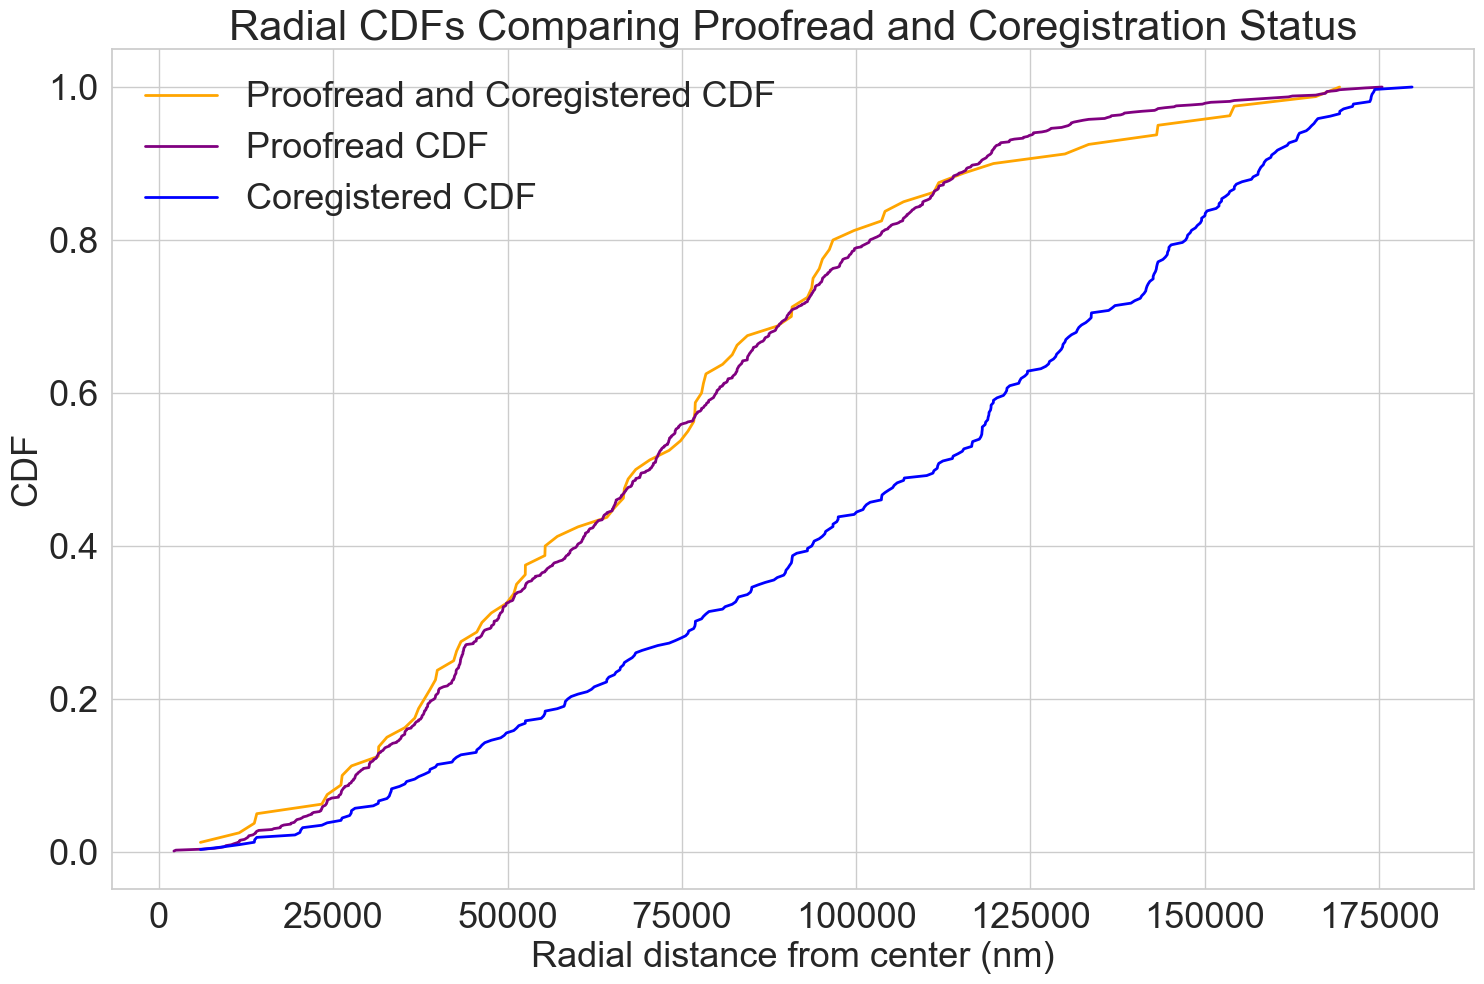

Proofread and Coregistered Cell Set Average Distance from Center (nm):  72176.98026056448
Proofread Cell Set Average Distance from Center (nm):  71736.30635755249
Coregistered Cell Set Average Distance from Center (nm):  103802.88070232961
Wilcoxon Rank-Sum Test (proofread < coregistered):
Statistic: -5.659, P-value: 7.592e-09


In [11]:
# CDF
def empirical_cdf(values):
    values_sorted = np.sort(values)
    cdf = np.arange(1, len(values_sorted) + 1) / len(values_sorted)
    return values_sorted, cdf

# compute CDFs
pre_r_sorted, pre_cdf = empirical_cdf(pre_r)
intermediate_r_sorted, intermediate_cdf = empirical_cdf(intermediate_r)
post_r_sorted, post_cdf = empirical_cdf(post_r)

# plot CDFs
plt.figure(figsize=(15, 10))

plt.plot(pre_r_sorted, pre_cdf, lw=2, color="orange", label="Proofread and Coregistered CDF")
plt.plot(intermediate_r_sorted, intermediate_cdf, lw=2, color="purple", label="Proofread CDF")
plt.plot(post_r_sorted, post_cdf, lw=2, color="blue", label="Coregistered CDF")

plt.xlabel("Radial distance from center (nm)", fontsize=26)
plt.ylabel("CDF", fontsize=26)
plt.tick_params(axis='both', which='major', labelsize=26)
plt.title("Radial CDFs Comparing Proofread and Coregistration Status", fontsize=30)
plt.legend(frameon=False, fontsize=26)
plt.tight_layout()
save_figure('cell_sets_CDFs_compared')
plt.show()
print('Proofread and Coregistered Cell Set Average Distance from Center (nm): ', np.mean(pre_r))
print('Proofread Cell Set Average Distance from Center (nm): ', np.mean(intermediate_r))
print('Coregistered Cell Set Average Distance from Center (nm): ', np.mean(post_r))
rank_sum_stat, rank_sum_p = stats.ranksums(pre_r, post_r, alternative='less')
print(f"Wilcoxon Rank-Sum Test (proofread < coregistered):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")

In [12]:
# quantiles
quantiles = [0.5, 0.6, 0.75, 0.85, 0.9, 0.95, 0.99]

print("Quantile   Pre_r     Intermediate r Post_r     Pre / Post")
for q in quantiles:
    q_pre = np.quantile(pre_r, q)
    q_inter = np.quantile(intermediate_r, q)
    q_post = np.quantile(post_r, q)
    print(f"{q:>6.2f}   {q_pre:8.3f}  {q_inter:8.3f}  {q_post:8.3f}   {q_pre/q_post:8.2f}")

from scipy.stats import ks_2samp

ks_stat, ks_p = ks_2samp(pre_r, post_r)
print('Pre v Post Cells')
print(f"KS statistic: {ks_stat:.3f}, p-value: {ks_p:.2e}")

Quantile   Pre_r     Intermediate r Post_r     Pre / Post
  0.50   69399.326  70426.292  111632.976       0.62
  0.60   77937.778  79969.321  121478.425       0.64
  0.75   94046.848  95209.893  142601.733       0.66
  0.85   107455.430  109639.045  152376.885       0.71
  0.90   120726.202  117648.451  158484.924       0.76
  0.95   143810.627  130507.635  165411.957       0.87
  0.99   166644.232  166216.562  173979.649       0.96
Pre v Post Cells
KS statistic: 0.375, p-value: 1.62e-08


In [13]:
# radial cutoff
# R_star = np.quantile(pre_r, 0.95)
# R_star = np.sqrt(cov_pre[0,0]) * 1.88
# R_star = np.sqrt(
#     (cov_pre[0,0] + cov_pre[1,1]) / 2
#     ) * 1.96

R_star = max(pre_r) * 0.75

print("R_star:", R_star)
print("fraction pre excluded from post-cell set:", np.mean(pre_r > R_star))
print("intermediate excluded fraction:", np.mean(intermediate_r > R_star))
print("fraction post excluded:", np.mean(post_r > R_star))
print()

R_star: 127004.51680802909
fraction pre excluded from post-cell set: 0.1
intermediate excluded fraction: 0.05868544600938967
fraction post excluded: 0.3682539682539683



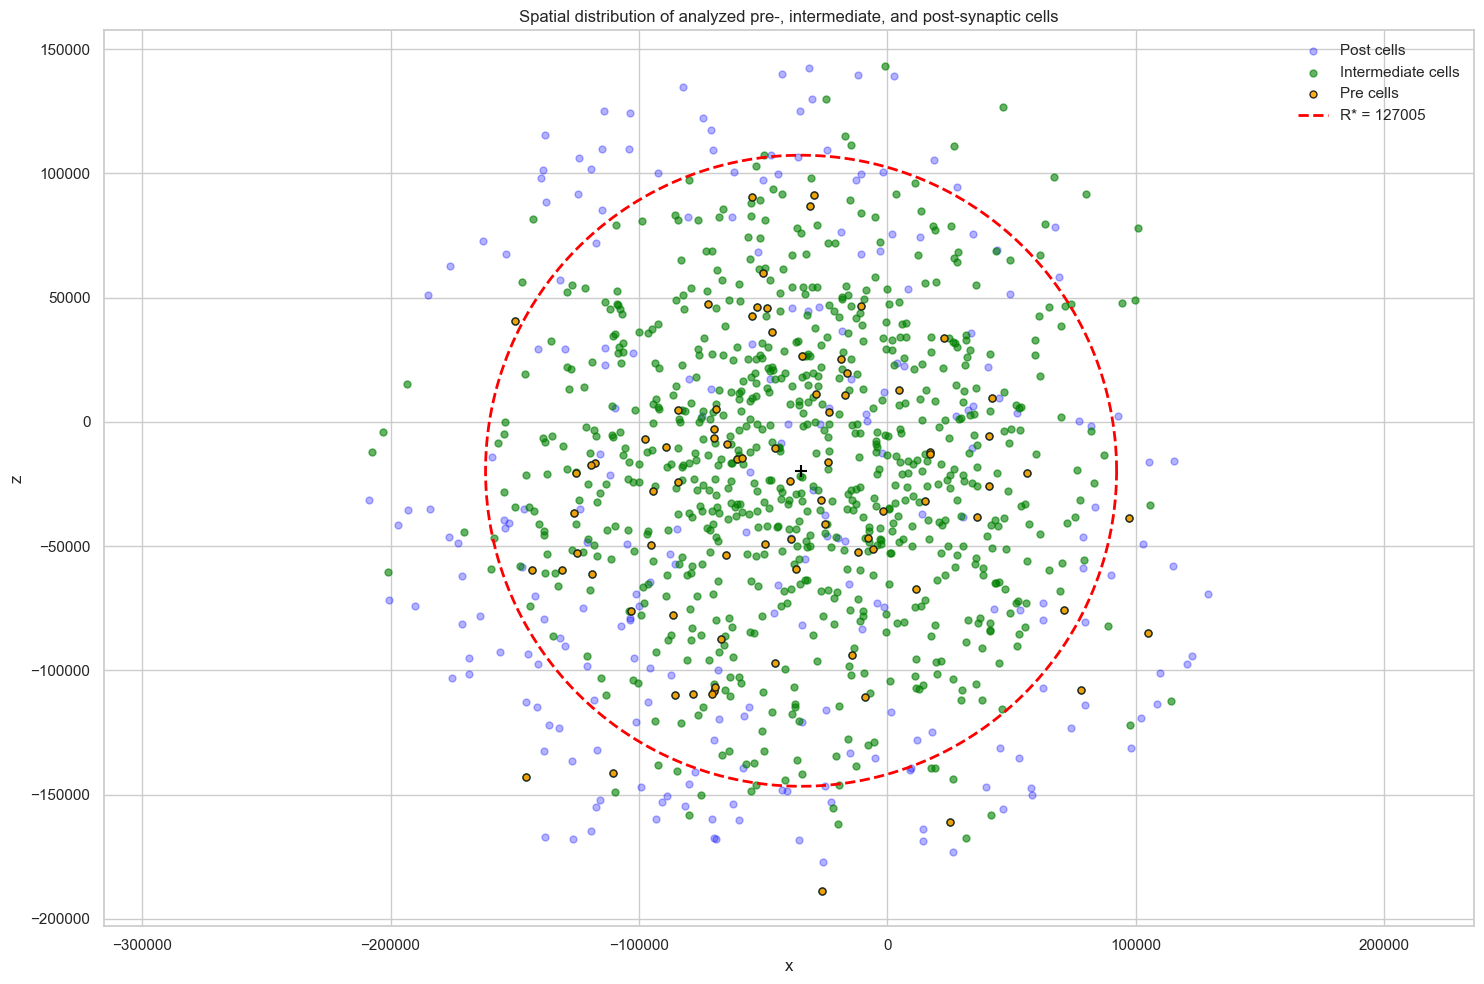

In [14]:
# --- scatter plot ---
plt.figure(figsize=(15, 10))

# plot posts first (background)
plt.scatter(
    post_xz[:, 0], post_xz[:, 1],
    s=25, alpha=0.3, color="blue", label="Post cells"
)
# intermediate
plt.scatter(
    intermediate_xz[:, 0], intermediate_xz[:, 1],
    s=25, alpha=0.6, color="green", label="Intermediate cells"
)

# plot pres on top
plt.scatter(
    pre_xz[:, 0], pre_xz[:, 1],
    s=25, alpha=0.9, color="orange", edgecolor="k", label="Pre cells"
)

# mark center
plt.scatter(center_x, center_z, c="black", s=80, marker="+")

theta = np.linspace(0, 2*np.pi, 500)
circle_x = center_x + R_star * np.cos(theta)
circle_z = center_z + R_star * np.sin(theta)

plt.plot(circle_x, circle_z, linestyle="--", linewidth=2,
         color="red", label=f"R* = {R_star:.0f}")

plt.legend(frameon=False)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("z")
plt.title("Spatial distribution of analyzed pre-, intermediate, and post-synaptic cells")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Chains Calculation

## RESTRICTION

In [15]:
assembly_post_cell_table['included'] = assembly_post_cell_table['radius'] <= R_star

assembly_post_cell_table_restricted = assembly_post_cell_table[
    assembly_post_cell_table['radius'] <= R_star
].copy()

assembly_post_root_ids_restricted = set(
    assembly_post_cell_table_restricted['pt_root_id'].values
)

In [16]:
## Define intermediary cell typing in dictionary
from collections import defaultdict
# intermediate_cell_table = intermediate_cell_table[intermediate_cell_table['radius'] <= R_star]
pt_root_id_to_cell_type = intermediate_cell_table.set_index('pt_root_id')['cell_type'].to_dict()
pt_root_id_to_cell_class = intermediate_cell_table.set_index('pt_root_id')['classification_system'].to_dict()

middle_cell_groups = defaultdict(set)

# Add class-level groups
for root_id, cls in pt_root_id_to_cell_class.items():
    middle_cell_groups[cls].add(root_id)

# Add type-level groups
for root_id, ctype in pt_root_id_to_cell_type.items():
    middle_cell_groups[ctype].add(root_id)

# Optional: freeze
middle_cell_groups = dict(middle_cell_groups)

# Synaptic Opportunity in Excluded v Included postcells

### closest pre-cell

In [17]:
import numpy as np
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu

pre_tree = cKDTree(pre_xz)

nearest_dist, _ = pre_tree.query(post_xz, k=1)

assembly_post_cell_table['nearest_pre_dist'] = nearest_dist

inside = assembly_post_cell_table.loc[assembly_post_cell_table['included'], 'nearest_pre_dist']
outside = assembly_post_cell_table.loc[~assembly_post_cell_table['included'], 'nearest_pre_dist']

u, p = mannwhitneyu(inside, outside, alternative='less')

print(f"Nearest-pre distance:")
print(f"  median inside  = {np.median(inside):.1f}")
print(f"  median outside = {np.median(outside):.1f}")
print(f"  MWU p-value (inside < outside): {p:.2e}")

Nearest-pre distance:
  median inside  = 7747.0
  median outside = 31605.5
  MWU p-value (inside < outside): 7.04e-27


### num pre-cells within distance d

In [18]:
# proxy distance scale: median distance from posts to nearest pres *inside R*
d = np.median(inside)
print(f"Using d = {d:.1f}")

counts = pre_tree.query_ball_point(post_xz, r=d)
assembly_post_cell_table['num_pres_within_d'] = [len(c) for c in counts]

inside = assembly_post_cell_table.loc[assembly_post_cell_table['included'], 'num_pres_within_d']
outside = assembly_post_cell_table.loc[~assembly_post_cell_table['included'], 'num_pres_within_d']

u, p = mannwhitneyu(inside, outside, alternative='greater')

print(f"Pres within d:")
print(f"  median inside  = {np.median(inside)}")
print(f"  median outside = {np.median(outside)}")
print(f"  MWU p-value (inside > outside): {p:.2e}")

Using d = 7747.0
Pres within d:
  median inside  = 1.0
  median outside = 0.0
  MWU p-value (inside > outside): 6.75e-15


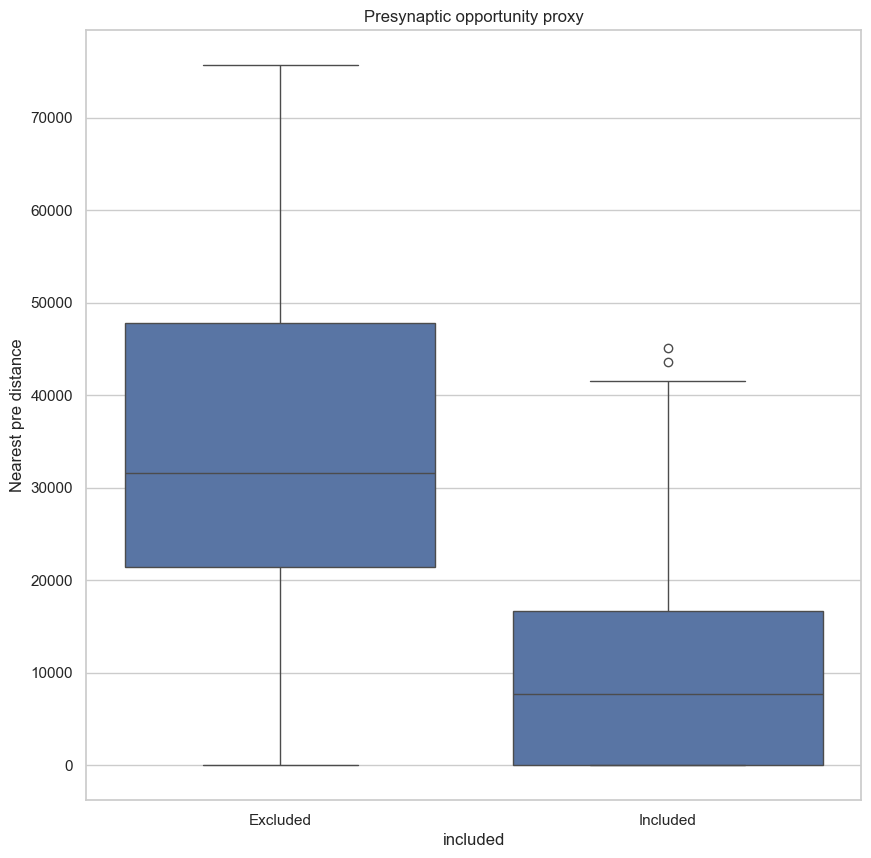

In [19]:
sns.boxplot(
    data=assembly_post_cell_table,
    x='included',
    y='nearest_pre_dist'
)
plt.xticks([0,1], ['Excluded', 'Included'])
plt.ylabel('Nearest pre distance')
plt.title('Presynaptic opportunity proxy')
plt.show()

### add cotravel